In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import statsmodels.api as sm
from sklearn import linear_model

from tqdm.notebook import tqdm

In [2]:
%cd ..

/Users/macos/Uni/1st_year/period_2/IntroML/homework


In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Problem 8

## Task a

In [4]:
path_spam_train = "E2/data_E2/spam_train.csv"
path_spam_test = "E2/data_E2/spam_test.csv"

In [5]:
df_train = pd.read_csv(path_spam_train)
df_test = pd.read_csv(path_spam_test)

In [6]:
df_train.head()

,MISSING_FROM,FROM_ADDR_WS,TVD_SPACE_RATIO,LOTS_OF_MONEY,T_FILL_THIS_FORM_SHORT,SPAM
0,1,0,0,1,0,0
1,1,0,0,1,0,0
2,1,0,0,1,0,0
3,1,0,0,1,0,0
4,1,0,1,0,0,0


In [7]:
cols_feat = ['MISSING_FROM', 'FROM_ADDR_WS', 'TVD_SPACE_RATIO', 'LOTS_OF_MONEY', 'T_FILL_THIS_FORM_SHORT']
col_trg = 'SPAM'

In [8]:
EPS = 1e-6

def calc_accu(ytrue: np.ndarray, ypred: np.ndarray):
    assert ytrue.shape == ypred.shape

    out = 1/len(ytrue) * (np.abs(ytrue - ypred) <= EPS).sum()

    return out

def calc_perplex(ytrue: np.ndarray, ypred_prob: np.ndarray):
    return np.exp(
        -np.sum(
            np.log(ypred_prob[np.arange(len(ytrue)), ytrue])
        ) / len(ytrue)
    )

In [9]:
Xtrain, ytrain = df_train[cols_feat], df_train[col_trg]
Xtest, ytest = df_test[cols_feat], df_test[col_trg]

In [10]:
classifier_unreg = linear_model.LogisticRegression(penalty=None, max_iter=5)

In [11]:
classifier_unreg.fit(Xtrain, ytrain)

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5, penalty=None)

### (i)

In [12]:
print(f"Model coefficients: {classifier_unreg.coef_[0]}")

Model coefficients: [-0.64595203 -0.71193417 -1.41737979 -0.54883611  2.97591372]


### (ii)

In [35]:
ytest_pred_unreg = classifier_unreg.predict(Xtest)
ytest_pred_prob_unreg = classifier_unreg.predict_proba(Xtest)

In [14]:
acc = calc_accu(ytest.to_numpy(), ytest_pred_unreg)
perp = calc_perplex(ytest.to_numpy(), ytest_pred_prob_unreg)

print(f"Accuracy  : {acc:.4f}")
print(f"Perplexity: {perp:.4f}")

Accuracy  : 0.8690
Perplexity: 1.4362


## Task b

In [15]:
best = {'acc': 0, 'per': 10, 'C': 0, 'model': None}
results = []

C = np.arange(0.1, 50, 0.2)
for c in tqdm(C):
    classifier = linear_model.LogisticRegression(penalty='l1', C=c, solver='liblinear', max_iter=500)

    classifier.fit(Xtrain, ytrain)
    ytest_pred = classifier.predict(Xtest)
    ytest_pred_prob = classifier.predict_proba(Xtest)

    acc = calc_accu(ytest.to_numpy(), ytest_pred)
    perp = calc_perplex(ytest.to_numpy(), ytest_pred_prob)

    results.append({
        'regularization': 1/c,
        'coef_1': classifier.coef_[0, 0],
        'coef_2': classifier.coef_[0, 1],
        'coef_3': classifier.coef_[0, 2],
        'coef_4': classifier.coef_[0, 3],
        'coef_5': classifier.coef_[0, 4],
        'accuracy': acc,
        'perplexity': perp
    })

    if acc > best['acc'] or perp < best['per']:
        best['acc'] = acc
        best['per'] = perp
        best['C'] = c
        best['model'] = classifier

best

  0%|          | 0/250 [00:00<?, ?it/s]

{'acc': 0.88,
 'per': 1.3909745241977731,
 'C': 3.3000000000000007,
 'model': LogisticRegression(C=3.3000000000000007, max_iter=500, penalty='l1',
                    solver='liblinear')}

In [16]:
df_results = pd.DataFrame.from_records(results)

df_results.head(20)

,regularization,coef_1,coef_2,coef_3,coef_4,coef_5,accuracy,perplexity
0,10.000000,0.0,0.000000,0.0,-0.258664,0.119007,0.661,1.851644
1,3.333333,0.0,0.000000,0.0,0.000000,2.200677,0.869,1.486820
2,2.000000,0.0,0.000000,0.0,0.000000,2.737533,0.869,1.451277
3,1.428571,0.0,0.000000,0.0,0.000000,3.009380,0.869,1.439731
4,1.111111,0.0,0.000000,0.0,0.030541,3.194760,0.869,1.433158
5,0.909091,0.0,-0.052437,0.0,0.301806,3.470923,0.869,1.419854
6,0.769231,0.0,-0.229870,0.0,0.553600,3.707341,0.869,1.409996
7,0.666667,0.0,-0.374767,0.0,0.764909,3.909612,0.869,1.403648
8,0.588235,0.0,-0.496885,0.0,0.946665,4.085893,0.869,1.399406
9,0.526316,0.0,-0.602731,0.0,1.108592,4.244661,0.869,1.396476


In [36]:
ytest_pred_prob_reg = best['model'].predict_proba(Xtest)

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be rem

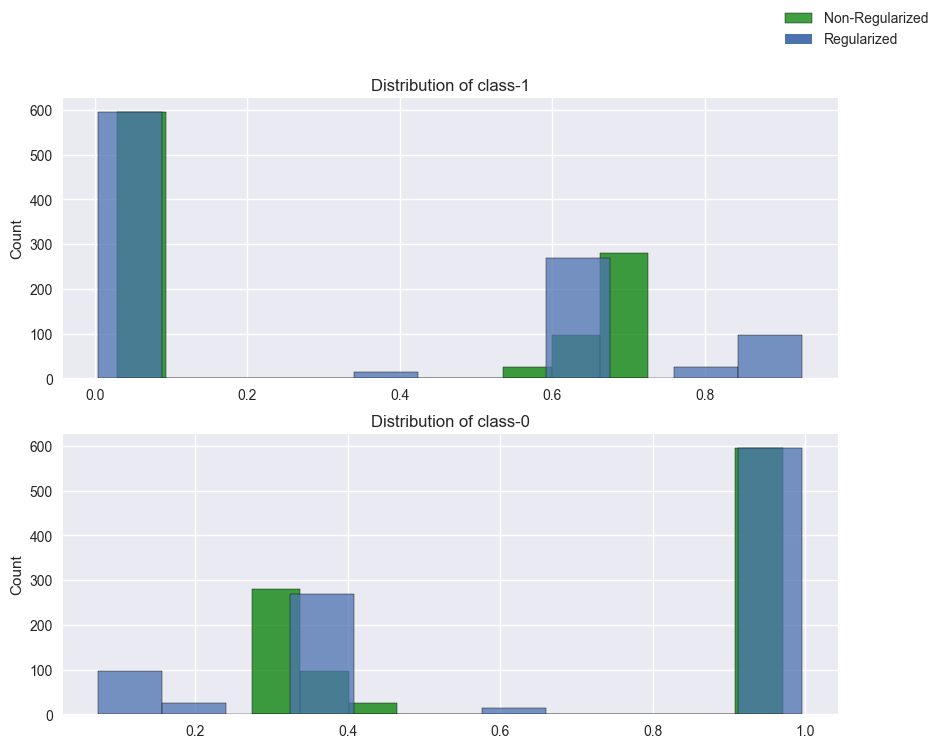

In [41]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(211)

ytest_prob_reg_ = best['model'].predict_proba(Xtest)[:, 1]
ytest_pred_prob_unreg_ = ytest_pred_prob_unreg[:, 1]
sns.histplot(ytest_pred_prob_unreg_, ax=ax, color='g')
sns.histplot(ytest_prob_reg_, ax=ax)
ax.set_title("Distribution of class-1")

ax = fig.add_subplot(212)

ytest_prob_reg_ = best['model'].predict_proba(Xtest)[:, 0]
ytest_pred_prob_unreg_ = ytest_pred_prob_unreg[:, 0]
sns.histplot(ytest_pred_prob_unreg_, ax=ax, color='g')
sns.histplot(ytest_prob_reg_, ax=ax)
ax.set_title("Distribution of class-0")

fig.legend(['Non-Regularized', 'Regularized'])
